# Audio Training

Train a Model with Audio MNIST data and analyse the results

In [1]:
from sdoml_task1.config import PROJECT_DIR, DATA_DIR, N_MFCC
from sdoml_task1.features import extract_features, decode_audio, build_feature_dataset
from sdoml_task1.dataset import AudioMNISTFeaturesDataset
from sdoml_task1.modeling.model import Net

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from datasets import load_dataset, Audio
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
import numpy as np
import torch

In [2]:
ds = load_dataset("gilkeyio/AudioMNIST")
ds = ds.cast_column("audio", Audio(decode=False))

X_train, y_train = build_feature_dataset(ds["train"])
X_test, y_test = build_feature_dataset(ds["test"])

print(X_train.shape, y_train.shape)  # ex: (24000, 26) (24000,)

Extract features: 100%|██████████| 6000/6000 [00:15<00:00, 385.00it/s]

(24000, 26) (24000,)


In [3]:
train_dataset = AudioMNISTFeaturesDataset(X_train, y_train)
test_dataset = AudioMNISTFeaturesDataset(X_test, y_test)

# Data loaders
loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

### MODEL DEFINITION

For training we will use a Multilayer Perceptron with an input of 26 neurons, two hidden layers of 64 and 32 neurons and a final output layer of 10 neurons according to the number of classes in the dataset (0-9 digits). 

More details:
- Optimizer: Adam (lr = 1e-4)
- loss function: Cross Entropy Loss

In [4]:
total_loss_train = []
total_accuracy_train = []
total_loss_valid = []
total_accuracy_valid = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = Net(input_dim=X_train.shape[1]).to(device)
opt = optim.Adam(net.parameters(), lr=1e-4) 
loss_fn = nn.CrossEntropyLoss()

epochs = 40

all_confusion_matrices = [] # Confusion matrice part

for epoch in range(epochs):
    net.train()
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    all_preds = [] # Confusion matrice part (prediction)
    all_labels = [] # Confusion matrice part (real answer)
    
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = net(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        opt.step()
        epoch_loss_train += loss.item() * xb.size(0)
        
        preds = out.argmax(1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
        
    cm = confusion_matrix(all_labels, all_preds)
    all_confusion_matrices.append(cm)

    train_loss = epoch_loss_train / total_train
    train_accuracy = correct_train / total_train
    total_loss_train.append(train_loss)
    total_accuracy_train.append(train_accuracy)


    net.eval()
    epoch_loss_valid = 0.0
    correct_valid = 0
    total_valid = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = net(xb)
            loss = loss_fn(out, yb)
            
            epoch_loss_valid += loss.item() * xb.size(0)
            preds = out.argmax(1)
            correct_valid += (preds == yb).sum().item()
            total_valid += yb.size(0)

    valid_loss = epoch_loss_valid / total_valid
    valid_accuracy = correct_valid / total_valid
    total_loss_valid.append(valid_loss)
    total_accuracy_valid.append(valid_accuracy)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Loss: {valid_loss:.4f} | Val Acc: {valid_accuracy:.4f}")

Epoch 1/40 | Train Loss: 8.4418 | Train Acc: 0.1212 | Val Loss: 3.0758 | Val Acc: 0.1850
Epoch 2/40 | Train Loss: 2.1943 | Train Acc: 0.3269 | Val Loss: 1.3877 | Val Acc: 0.4795
Epoch 3/40 | Train Loss: 1.1323 | Train Acc: 0.5962 | Val Loss: 0.9328 | Val Acc: 0.6717
Epoch 4/40 | Train Loss: 0.7774 | Train Acc: 0.7398 | Val Loss: 0.7250 | Val Acc: 0.7527
Epoch 5/40 | Train Loss: 0.5920 | Train Acc: 0.8168 | Val Loss: 0.6040 | Val Acc: 0.7993
Epoch 6/40 | Train Loss: 0.4782 | Train Acc: 0.8627 | Val Loss: 0.5101 | Val Acc: 0.8423
Epoch 7/40 | Train Loss: 0.4070 | Train Acc: 0.8839 | Val Loss: 0.4736 | Val Acc: 0.8490
Epoch 8/40 | Train Loss: 0.3565 | Train Acc: 0.8995 | Val Loss: 0.4183 | Val Acc: 0.8682
Epoch 9/40 | Train Loss: 0.3168 | Train Acc: 0.9119 | Val Loss: 0.3899 | Val Acc: 0.8802
Epoch 10/40 | Train Loss: 0.2879 | Train Acc: 0.9193 | Val Loss: 0.3712 | Val Acc: 0.8850
Epoch 11/40 | Train Loss: 0.2623 | Train Acc: 0.9252 | Val Loss: 0.3675 | Val Acc: 0.8802
Epoch 12/40 | Train

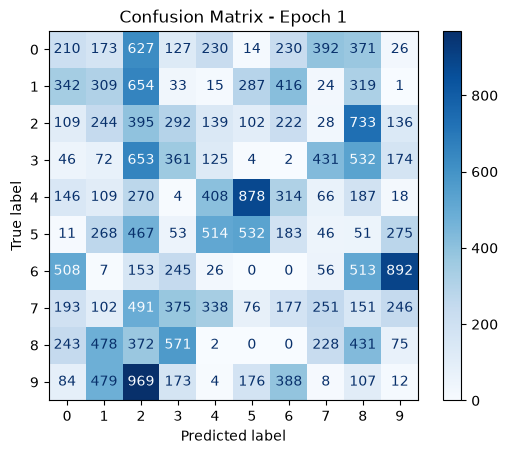

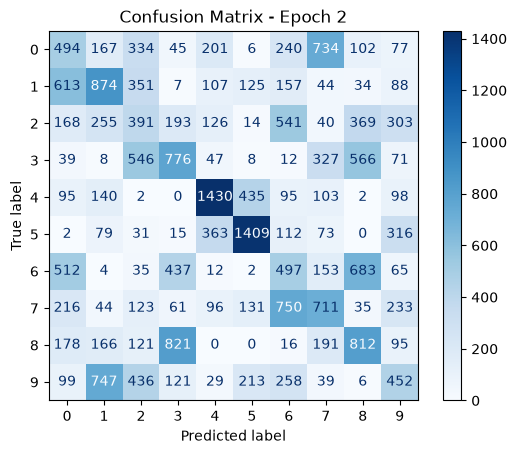

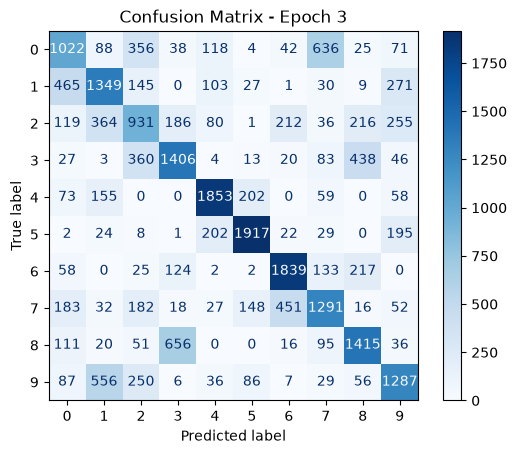

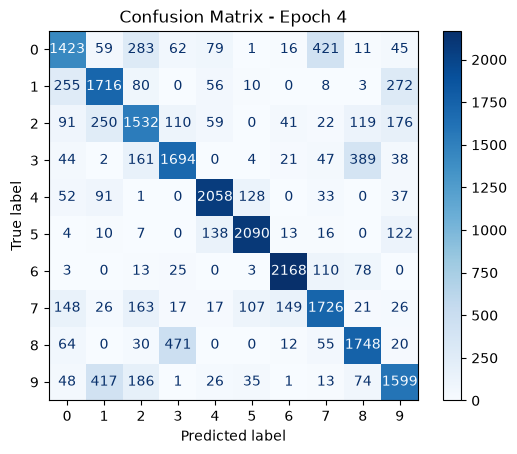

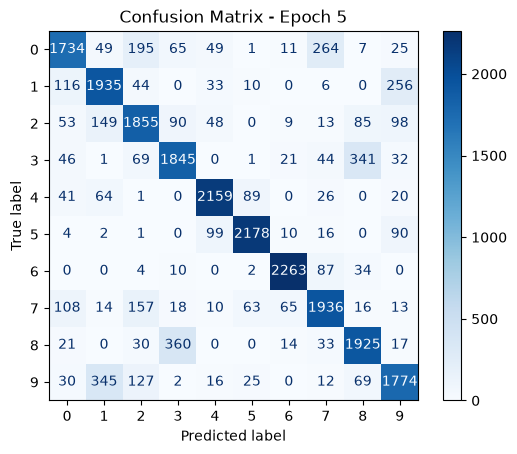

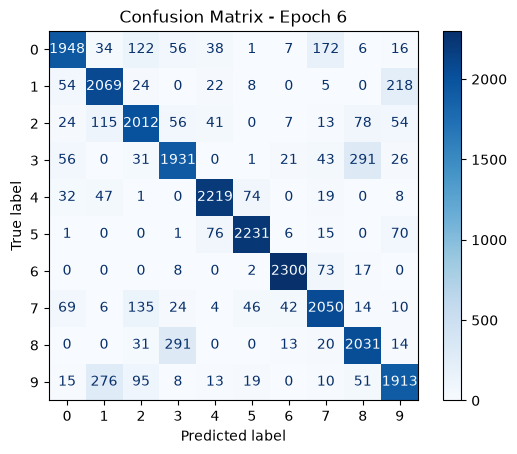

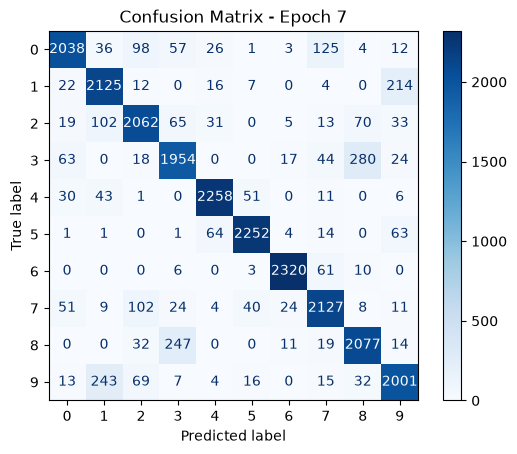

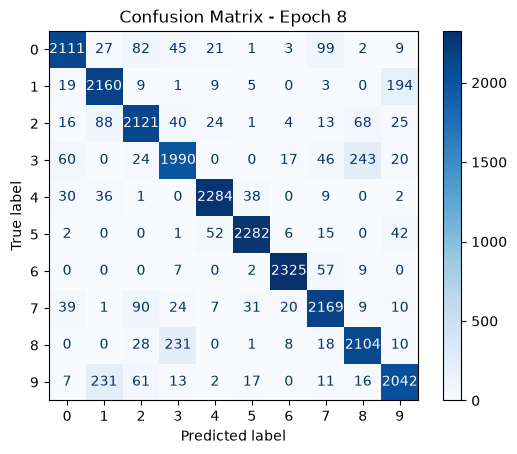

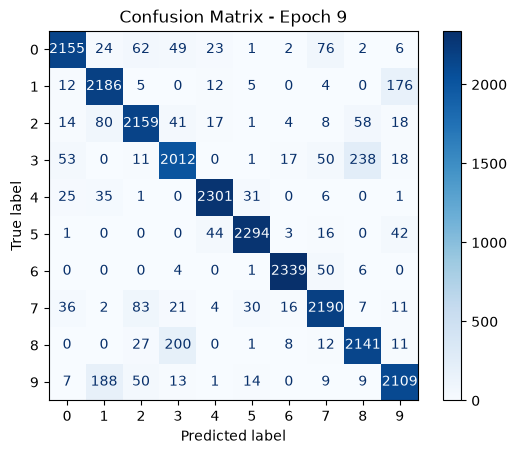

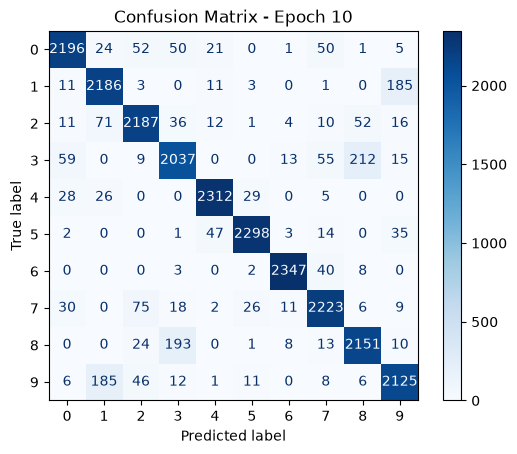

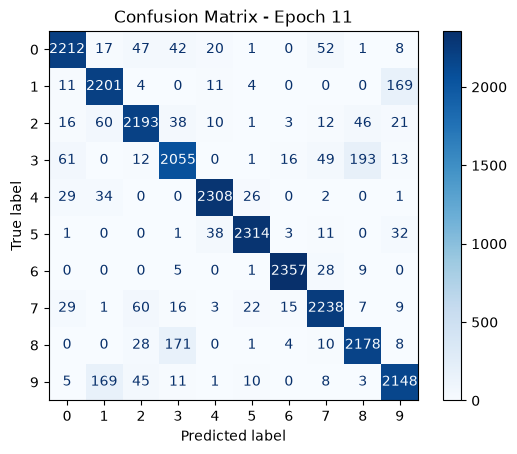

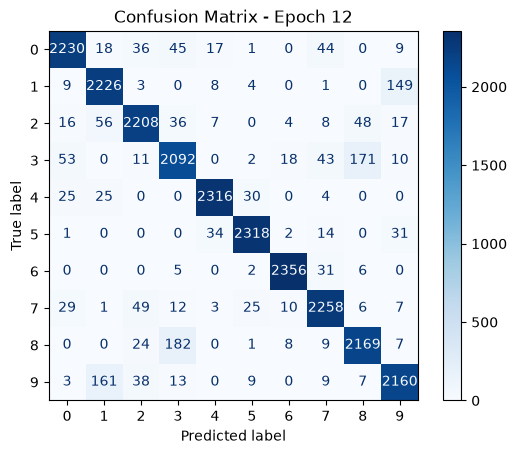

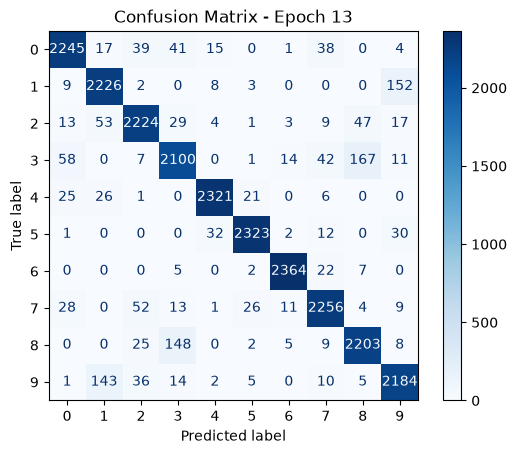

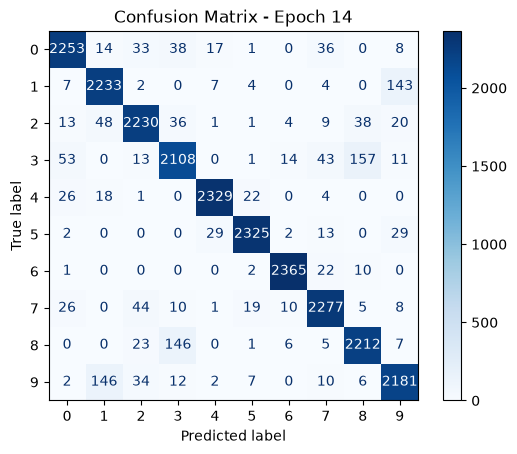

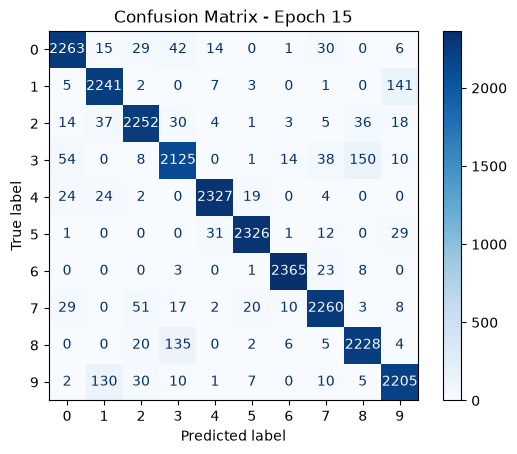

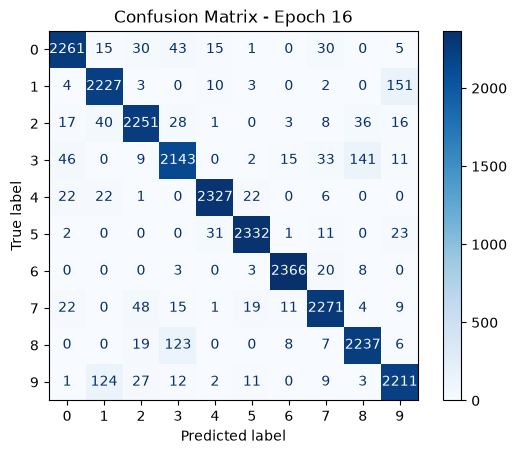

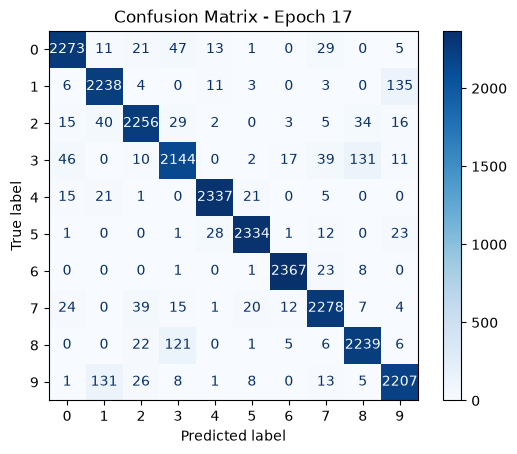

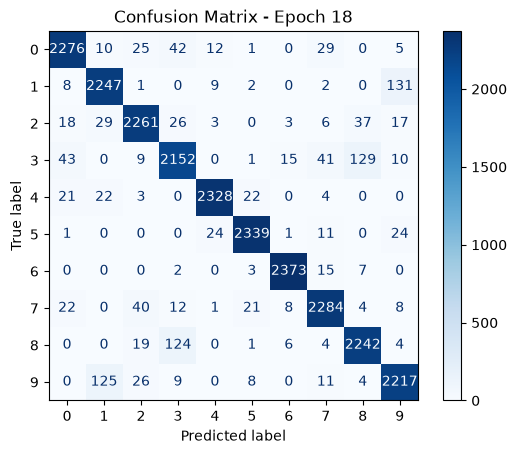

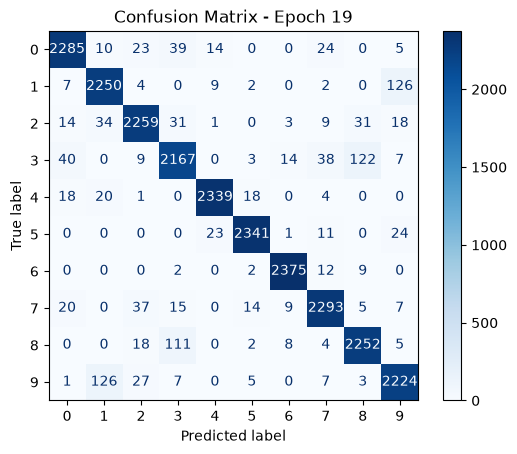

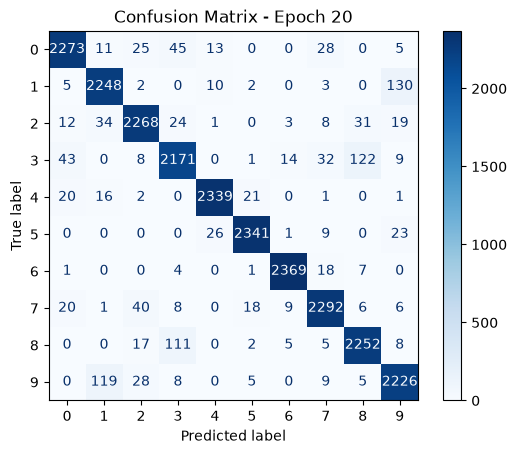

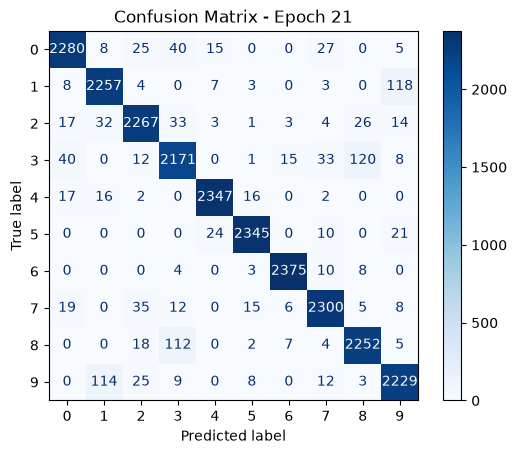

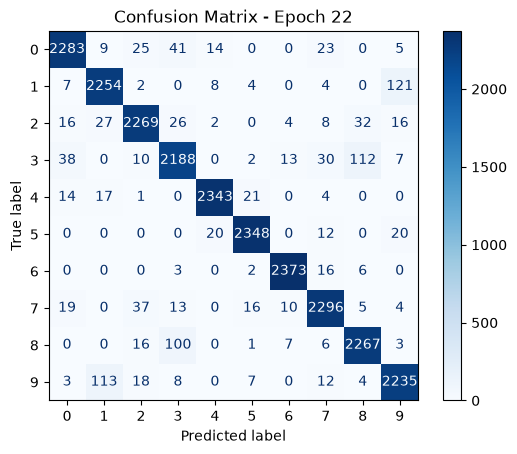

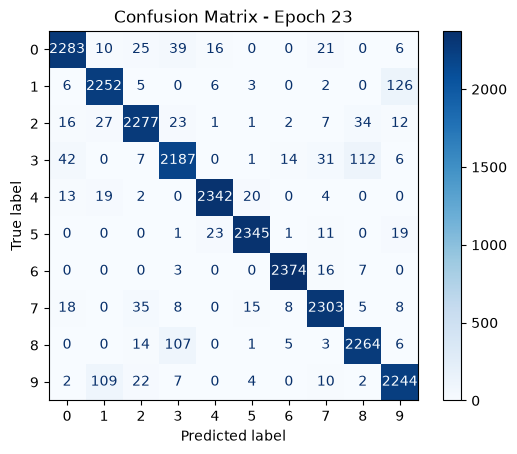

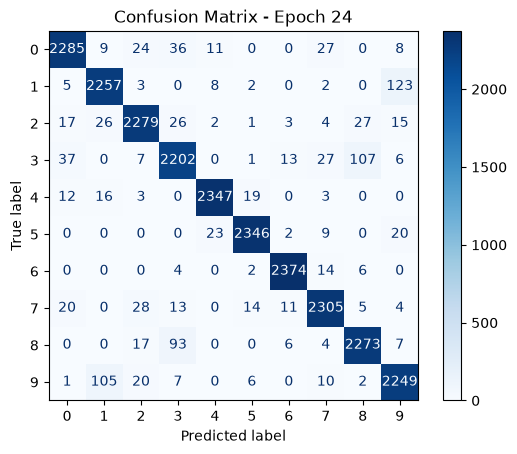

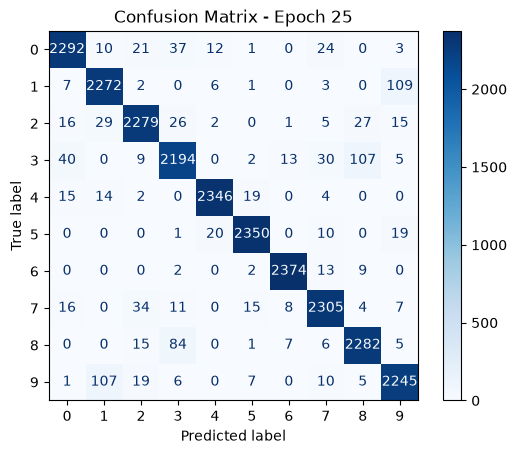

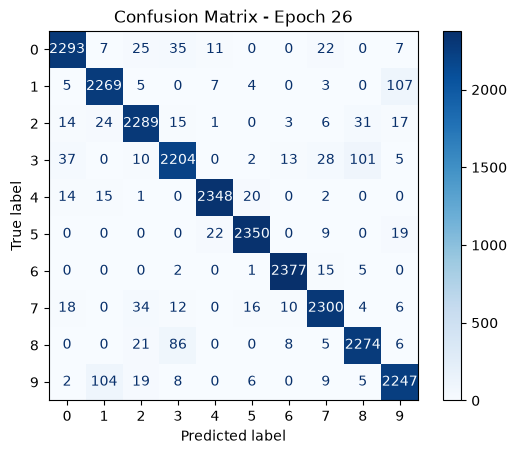

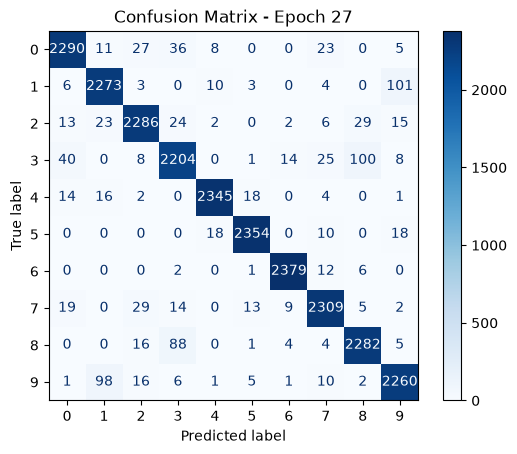

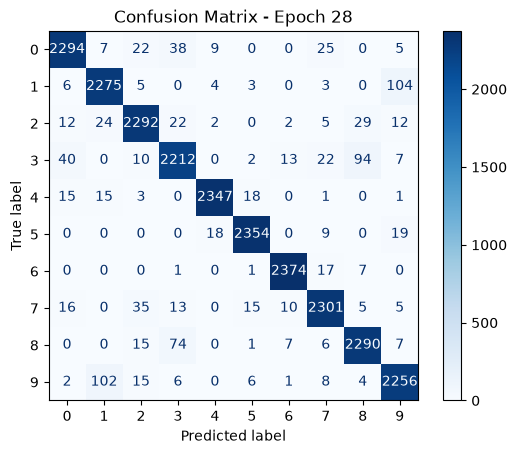

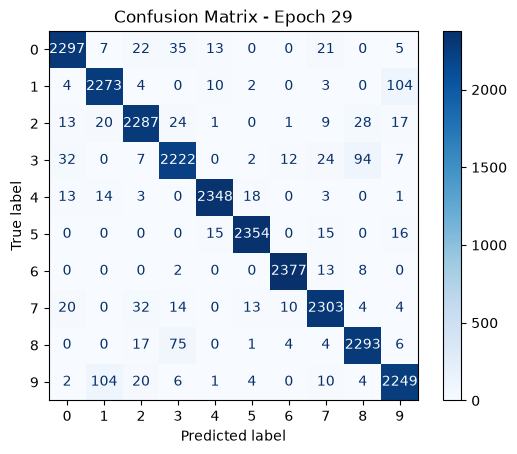

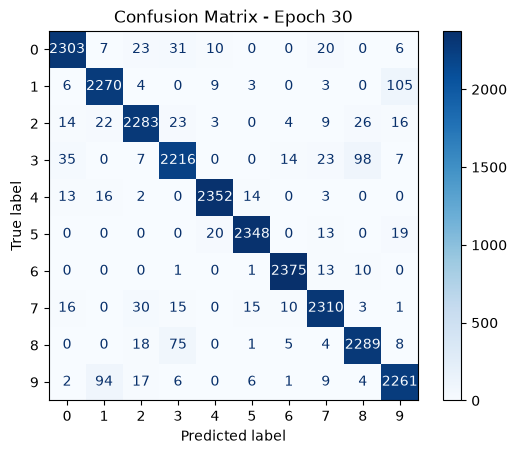

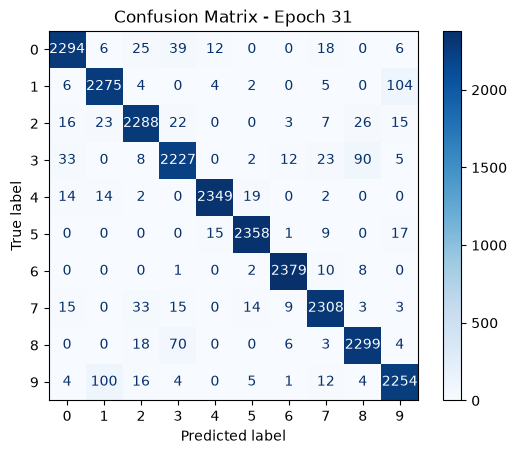

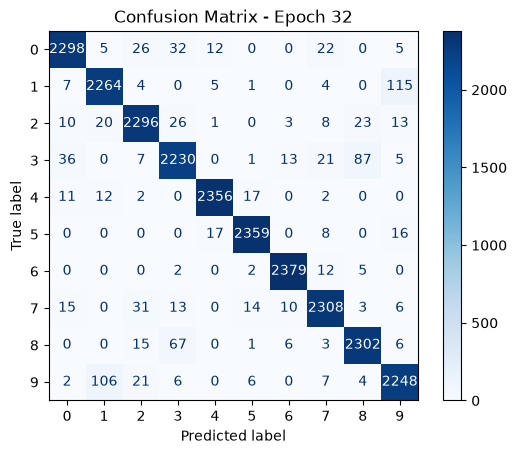

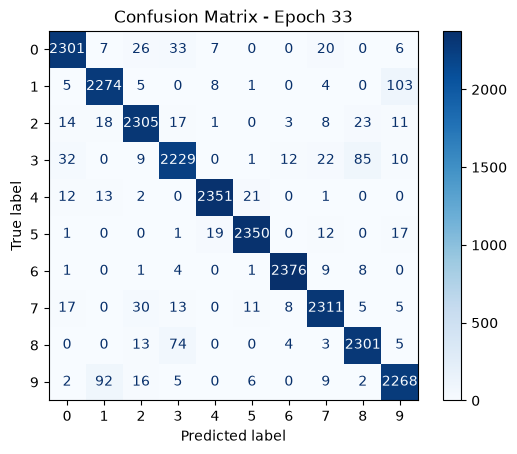

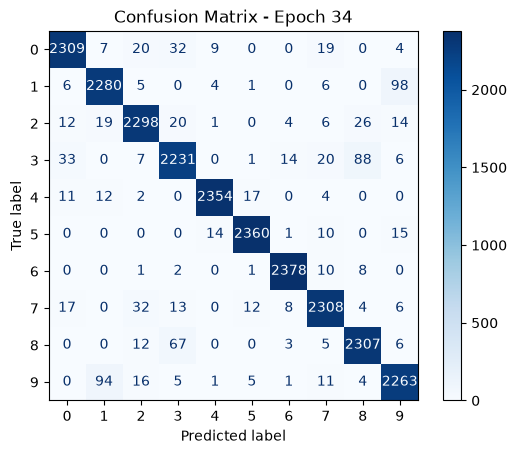

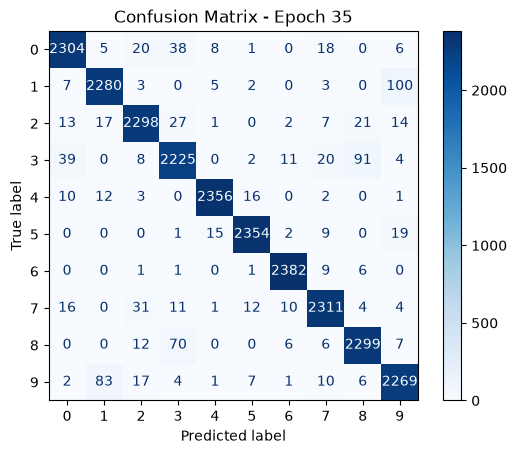

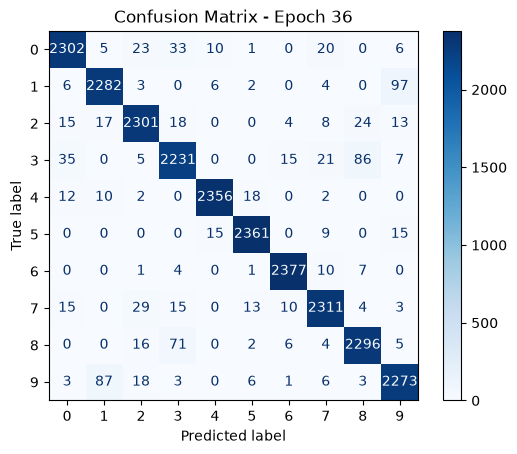

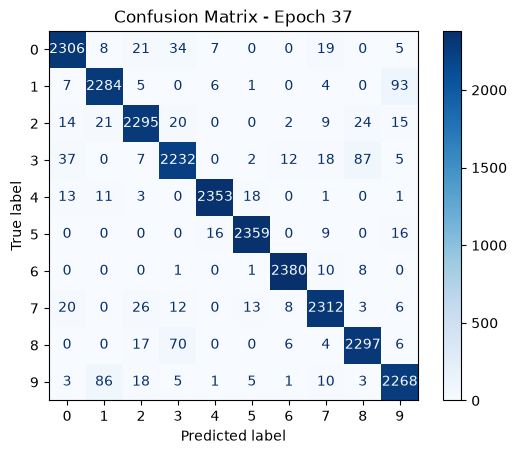

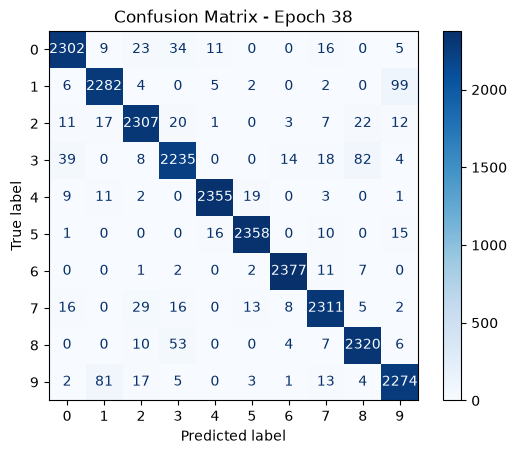

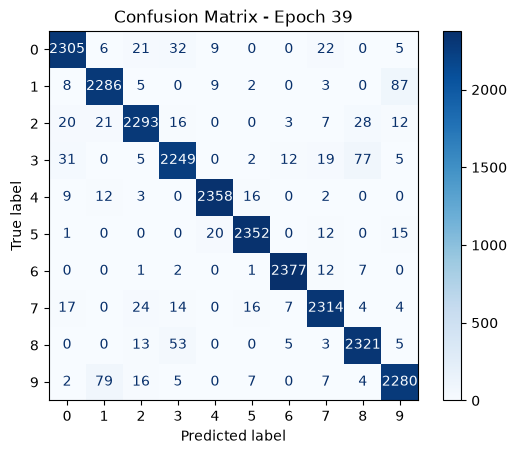

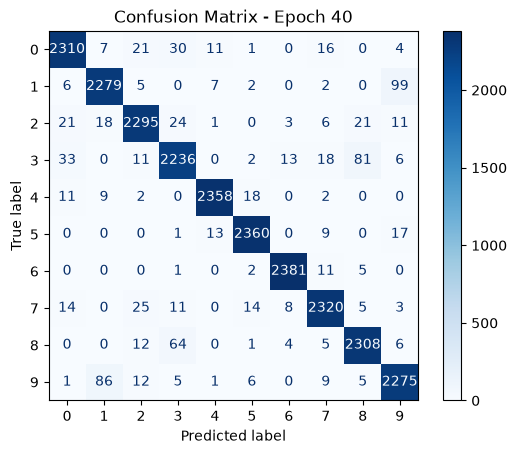

In [5]:
for i, cm in enumerate(all_confusion_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - Epoch {i+1}")
    plt.show()

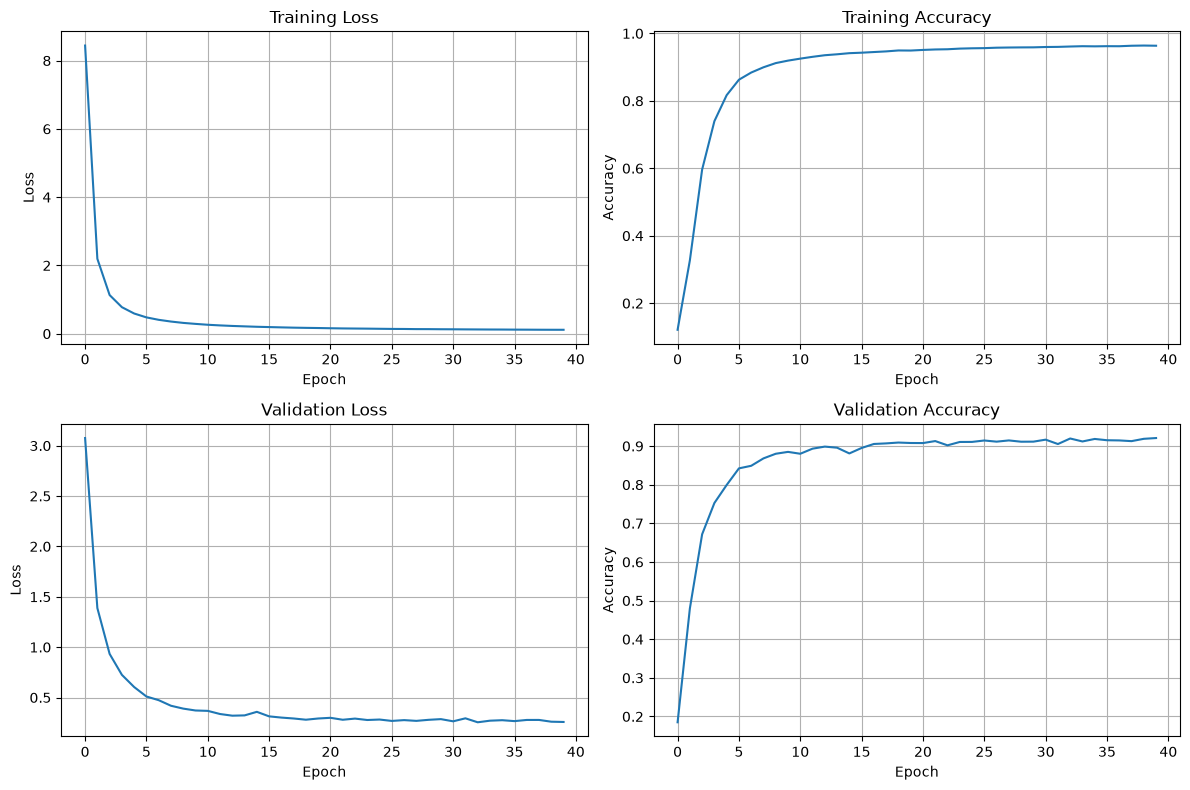

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
ax1, ax2, ax3, ax4 = axs.flatten()

ax1.plot(total_loss_train)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid()

ax2.plot(total_accuracy_train)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.grid()

ax3.plot(total_loss_valid)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.set_title('Validation Loss')
ax3.grid()

ax4.plot(total_accuracy_valid)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy')
ax4.set_title('Validation Accuracy')  
ax4.grid()

plt.tight_layout()
plt.show()